# **Modelos de recomendación**

Modelos de aprendizaje no supervisado que buscan recomendar escenarios a individuos con comportamientos similares. Pueden ser

* Filtro colaborativo: generar recomendaciones a partir de la agrupación de ususarios con comportamientos similares. se pueden hacer x 2 sentidos, por recomendacion de usuario o recomendacion de elementos. user-based/item-based. puedo aglomerar por individuos con gustos similares y x consumo y puedo aglomerar por los elementos consumidos. se entiende a través de agrupamiento.

* Basados en contenido: Utilizan el perfil del usuario y los artículos sobre los que demuestran preferencia para la recomendación. elementos que denotan la preferencia y empiezna a definir métricas para la recomendación

* Basados en popularidad: Utilizan calificaciones para establecer la recomendación. 

Estos dos últimos utilizan herramientas de similitud específica, aplicando 2 tipos de distancia:

- correlación, ya sea de pearson que solamnete identifica relaciones lineales, o la de spearman que nos habla de posibles comportamientos o relaciones no lineales

pearson: $φp = \frac{( \sum_{i=1}^{n}(Xi - \bar{X}))}{\sqrt{\sum_{i=1}^{n}(Xi - \bar{X})^2  \sum_{i=1}^{n}(Yi - \bar{Y})^2}}$

Spearman:$1 - \frac{G\sum_{i=1}^{n}(di)^2}{n(n^2 - 1)}$
Por lo tanto, $di = (Xi - Yi)$

- coseno:  $sim(x,y) = \frac{X * Y}{||X|| * ||Y||}$


# **1. Entendimiento del negocio**

Una empresa de turismo quiere sugerir a sus asociados qué restaurantes pueden visitar en la zona de playa de california. contanod con información de reseñas de los restaurantes realizadas x otros usuarios.

# **2. Enfoque analítico**

Construir un modelo de recomendacipon que sea validado x el usuario

# **3.Requerimeinto de los datos**

Se necesitan datos de las reseñas o calificaciones realizadas por los usuraios de los restaurantes 

# **4. Recolección de los datos**


In [2]:
import pandas as pd
import numpy as np 

In [3]:
data = pd.read_csv(r'C:\Users\Sebastian\OneDrive\Escritorio\CC\sb_restaurants_clean.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)
data 

,user_id,business_id,stars,name
0,IlWLPCRQp8iqX0X-ExQccQ,bdfZdB2MTXlT6-RBjSIpQg,4.0,Pho Bistro
1,WSMIRegvrsEgFGEraf_LwQ,bdfZdB2MTXlT6-RBjSIpQg,5.0,Pho Bistro
2,2odfcvFhkb8SedI3vCLpmQ,bdfZdB2MTXlT6-RBjSIpQg,5.0,Pho Bistro
3,OEKu0Rts0spELpbnucDKmA,bdfZdB2MTXlT6-RBjSIpQg,5.0,Pho Bistro
4,4MSEWnnxKhNdh7GgNHM-YQ,bdfZdB2MTXlT6-RBjSIpQg,4.0,Pho Bistro
...,...,...,...,...
37825,pc3rsR3ji6na9OKucyXRuw,nhOMsw22-rz9kXSKwBZYAQ,2.0,Miracle At The Funk Zone
37826,LuPUwdJMWqahkSIb8SrI9w,nhOMsw22-rz9kXSKwBZYAQ,2.0,Miracle At The Funk Zone
37827,iubWB0-vNBWR3E_ZPeKPjA,nhOMsw22-rz9kXSKwBZYAQ,4.0,Miracle At The Funk Zone
37828,A4bsa7ykYRVCnb4h2vZALw,nhOMsw22-rz9kXSKwBZYAQ,5.0,Miracle At The Funk Zone


# **5.Exploración de los datos**

- Nulidad de los datos
- cantidad de registros x elemento
- Exploración de las clasificaciones

In [4]:
#nulidad
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37830 entries, 0 to 37829
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      37830 non-null  object 
 1   business_id  37830 non-null  object 
 2   stars        37830 non-null  float64
 3   name         37830 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [5]:
total_restaurants = data['name'].nunique()
total_users = data['user_id'].nunique()
total_reviews = data['stars'].count()
print(f'La cantidad de restaurantes es: {total_restaurants}\nLa cantidad de usuarios es: {total_users}\nLa cantidad de reseñas es: {total_reviews}')

La cantidad de restaurantes es: 659
La cantidad de usuarios es: 23468
La cantidad de reseñas es: 37830


![Imagen de WhatsApp 2025-10-29 a las 08.50.55_548b0cec.jpg](<attachment:Imagen de WhatsApp 2025-10-29 a las 08.50.55_548b0cec.jpg>)
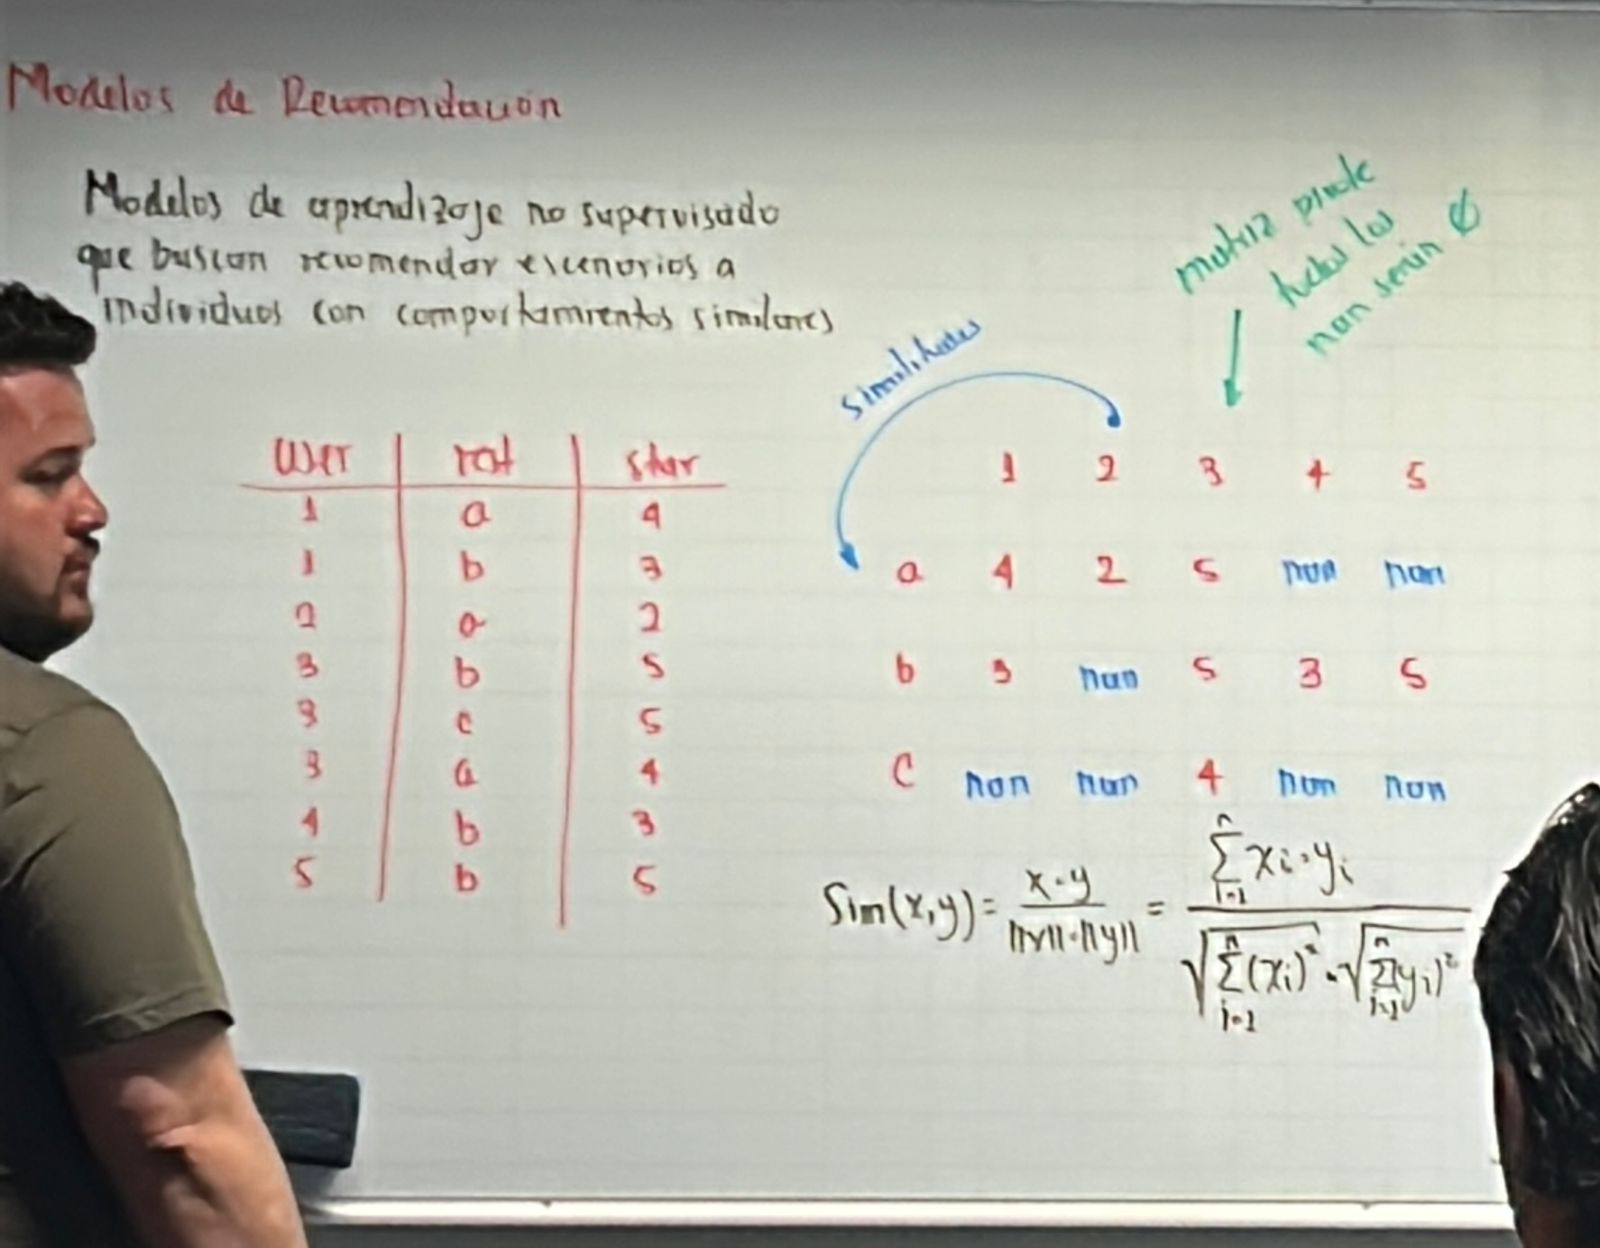

In [6]:
#clasificaciones por un usuario específico
idx = (data['user_id'] == 'IlWLPCRQp8iqX0X-ExQccQ')
print(f'El total de restauranres calificados por el usuario es:', idx.sum())
data[idx]

El total de restauranres calificados por el usuario es: 2


,user_id,business_id,stars,name
0,IlWLPCRQp8iqX0X-ExQccQ,bdfZdB2MTXlT6-RBjSIpQg,4.0,Pho Bistro
3399,IlWLPCRQp8iqX0X-ExQccQ,sNyHfboSOs-ESN76cYFfTA,5.0,Santorini Greek Island Grill


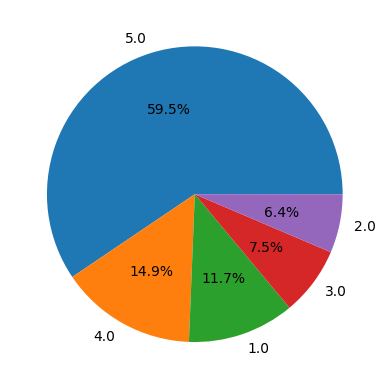

In [7]:
import matplotlib.pyplot as plt
plt.pie(x = data.stars.value_counts(), labels = data.stars.value_counts().index, autopct='%0.1f%%')
plt.show()

# **6. Construcción del modelo**

- Crear la matriz pivote
- Proceso de reducción de la dimensionalidad
- Construir las matrices de similitud para la recomendación

In [8]:
user_restaurant = data.pivot_table(values = 'stars', index = 'name', columns = 'user_id', fill_value = 0)
user_restaurant

user_id,---zemaUC8WeJeWKqS6p9Q,--2F5G5LKt3h2cAXJbZptg,--7XOV5T9yZR5w1DIy_Dog,--8YG4BoOWFGjdh9Fxop-w,--_QWYpJ2In2IgW_bouSuQ,--kinfHwmtdjz03g8B8z8Q,-0-Cbo-4YzKmoJXpnckwbg,-0-TtVhV4PIUoDpUCOC0uQ,-06H6BQ5cS5A5Jpd_iiwCA,-09MjuD1Q0KwSYwdYbAzMw,...,zyP0-AxYAb61wVroBgR0ng,zyQcIz_DR9CM-Tah3B7Tfw,zyWX5BNC9JhEsrrzaK-X9g,zyakHeX-9wVqU33jn6NMtA,zym3VpXHS4YWRMXUJ-MxsQ,zyvAj-SNHqHnrTN0X5_adA,zyzSePGcKiiA15e1takl4g,zzkJpm2B4PNPHnXg-CMyog,zzudZ50i88aStmQ6Ft1cVA,zzzGgfvrSJ4AQeKtcgocIw
name,,,,,,,,,,,,,,,,,,,,,
101 Deli,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1114 Sports Bar & Games,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Eggs & Pizza,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Slice of Woodstock's,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AH Juice Organics,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zaytoon,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen Yai Thai Cuisine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zizzo's Coffeehouse,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **Descomposición por valores singulares**

Reducir la cantidad de características x medio de la identificación de vectores propios buscando o manteniendo la máxima varianza, toma una matrix existente y busca que sea una defnición cercana a los diferentes vectores ortogonales que definen las diferentes combinaciones producto con sigma q son los valores singulares de la matrix ordenados x la varianza y Vt que son los vecotes ortogonales de las de combinaciones de las columnas.

$A = U \sum_\ V^T$

k = cantidad de componentes deseados

Buscamos reducir el tamaño de A, reduciendo sigma.

In [9]:
from sklearn.decomposition import TruncatedSVD
SVD = TruncatedSVD(n_components=659, random_state=42)
SVD.fit(user_restaurant)

,n_components,659
,algorithm,'randomized'
,n_iter,5
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42
,tol,0.0


In [10]:
num_sv = 7
print('La cantidad de información explicada con los primeros %d vestores singulares es: '%num_sv)
print('%0.2f%%' % (100 * (1 - (SVD.singular_values_[0:num_sv]).sum()/(SVD.singular_values_).sum())))

La cantidad de información explicada con los primeros 7 vestores singulares es: 
95.83%


In [11]:
num_sv = 5
print('La cantidad de información explicada con los primeros %d vestores singulares es: '%num_sv)
print('%0.2f%%' % (100 * (1 - (SVD.singular_values_[0:num_sv]).sum()/(SVD.singular_values_).sum())))

La cantidad de información explicada con los primeros 5 vestores singulares es: 
96.87%


In [12]:
SVD_5 = TruncatedSVD(n_components=5, random_state=42)
result_matrix = SVD_5.fit_transform(user_restaurant)
result_matrix

array([[ 0.08325865,  0.0827159 ,  0.15625382,  0.03734063, -0.03711163],
       [ 2.22545948,  1.18559033,  0.81729322,  2.08507674, -0.9080326 ],
       [ 1.65760476,  0.62004894,  0.43417323,  1.29517647, -0.26026814],
       ...,
       [ 0.09117129,  0.02401858,  0.03505825,  0.06723986, -0.02856405],
       [ 1.88249287,  1.20883569,  1.13118453,  0.92939539, -0.46709159],
       [ 0.2850191 ,  0.08991918, -0.01642041,  0.06385593, -0.06107389]])

In [13]:
from sklearn.metrics.pairwise import cosine_similarity
corrMtx = np.corrcoef(result_matrix)
cosineMtx = cosine_similarity(result_matrix)
corrSpMtx = pd.DataFrame(result_matrix).corr(method='spearman')

# Correlación de Pearson

In [14]:
corrMtx

array([[1.        , 0.48612014, 0.34456424, ..., 0.49746953, 0.74845422,
        0.26249176],
       [0.48612014, 1.        , 0.96755048, ..., 0.96533114, 0.88387554,
        0.78073389],
       [0.34456424, 0.96755048, 1.        , ..., 0.97918247, 0.83916384,
        0.86964616],
       ...,
       [0.49746953, 0.96533114, 0.97918247, ..., 1.        , 0.88425923,
        0.81955961],
       [0.74845422, 0.88387554, 0.83916384, ..., 0.88425923, 1.        ,
        0.81619977],
       [0.26249176, 0.78073389, 0.86964616, ..., 0.81955961, 0.81619977,
        1.        ]])

In [15]:
corrMtx[0:5, 0:5]

array([[1.        , 0.48612014, 0.34456424, 0.86775303, 0.64899054],
       [0.48612014, 1.        , 0.96755048, 0.7913078 , 0.97006447],
       [0.34456424, 0.96755048, 1.        , 0.65070888, 0.89952492],
       [0.86775303, 0.7913078 , 0.65070888, 1.        , 0.86323812],
       [0.64899054, 0.97006447, 0.89952492, 0.86323812, 1.        ]])

In [16]:
liked = 'Taco Bell'
names = user_restaurant.T.columns
names_list = list(names)
id_liked = names_list.index(liked)
corr_recom = corrMtx[id_liked]
corr_recom[0:10]

array([0.2174252 , 0.60299846, 0.73710169, 0.39440022, 0.48431101,
       0.48959878, 0.38728345, 0.32087249, 0.55873588, 0.67532528])

In [17]:
corr_recom[id_liked]

1.0

In [18]:
print('Recomendaciones: ')
list(names[(corr_recom > 0.95) & (corr_recom < 0.99)])

Recomendaciones: 


['Bristol Farms - Santa Barbara',
 'Del Valle Grill',
 'El Rincon Bohemio',
 'Freebirds',
 'Fresco Cafe',
 'Gladden and Sons Produce',
 'Habit Burger Grill',
 "Jeannine's Bakery & Restaurant",
 "Norton's Pastrami & Deli",
 'Panaderia Veronica',
 'Pressed',
 'Revolver',
 'Starbucks',
 'Subway',
 'Taqueria El Bajio',
 'The Daily Grind',
 'The Spot',
 "Wendy's",
 'Zookers Cafe']

In [19]:
ids = (corr_recom > 0.95) & (corr_recom < 0.99)
tmp = list()
for i in range(len(names[ids])):
    tmp.append((names[ids][i], corr_recom[ids][i]))
sorted(tmp, key=lambda x:x[0], reverse=True)

[('Zookers Cafe', 0.9583004344956515),
 ("Wendy's", 0.9520339008051109),
 ('The Spot', 0.9810166772724536),
 ('The Daily Grind', 0.968430895887047),
 ('Taqueria El Bajio', 0.980357970013199),
 ('Subway', 0.9588960452271417),
 ('Starbucks', 0.9528886415061746),
 ('Revolver', 0.9638076056145891),
 ('Pressed', 0.9658292385491791),
 ('Panaderia Veronica', 0.9566537006813488),
 ("Norton's Pastrami & Deli", 0.9619481721566338),
 ("Jeannine's Bakery & Restaurant", 0.9576559742148801),
 ('Habit Burger Grill', 0.9560523694457623),
 ('Gladden and Sons Produce', 0.970944443045393),
 ('Fresco Cafe', 0.9652135092893926),
 ('Freebirds', 0.95906138599961),
 ('El Rincon Bohemio', 0.9804296607202807),
 ('Del Valle Grill', 0.9573652106288245),
 ('Bristol Farms - Santa Barbara', 0.9562925605387236)]

# Recomendaciones usando similitud de coseno 


In [20]:



liked = 'Taco Bell'
names = user_restaurant.T.columns
names_list = list(names)
id_liked = names_list.index(liked)
corr_recom = cosineMtx[id_liked]
corr_recom[0:10]
print('Recomendaciones: ')
list(names[(corr_recom > 0.95) & (corr_recom < 0.99)])

ids = (corr_recom > 0.95) & (corr_recom < 0.99)
tmp = list()
for i in range(len(names[ids])):
    tmp.append((names[ids][i], corr_recom[ids][i]))
sorted(tmp, key=lambda x:x[1], reverse=True)


Recomendaciones: 


[('Habit Burger Grill', 0.9896674166203614),
 ('Subway', 0.9893193623964881),
 ('El Rincon Bohemio', 0.988788540530434),
 ('The Spot', 0.9885362266523459),
 ("Z's - Taphouse & Grill", 0.9831007569392579),
 ('Revolver', 0.9827165290445486),
 ("Bree'osh", 0.9822383074277908),
 ('Ca’Dario - Montecito', 0.9778528259650728),
 ('Sushi GoGo', 0.9777154257338205),
 ("Rusty's Pizza Parlor", 0.9760836078140225),
 ("Mulligan's Cafe & Bar", 0.9758962776463653),
 ('Kanaloa Seafood', 0.9751119635105775),
 ("Wendy's", 0.9727829884667999),
 ('Hibachi Steak House & Sushi Bar', 0.9711802999381667),
 ('Corazon Cocina', 0.9710902302744406),
 ('Finch & Fork', 0.9707856908528367),
 ("Super Cuca's Taqueria", 0.9701793885058732),
 ('The Drunken Crab', 0.9695797609097921),
 ('The Worker Bee Cafe', 0.9679563280019468),
 ("Rudy's Restaurant No 1", 0.9674787702455465),
 ('Del Valle Grill', 0.9657640106206504),
 ('Meun Fan Thai Cafe', 0.9647514356217216),
 ('Night Lizard Brewing Company', 0.9646378918738743),
 ('M

In [21]:


corrSpMtx.index[4]
corrSpMtx.columns[4]


4

In [22]:

corrSpMtx = user_restaurant.T.corr(method='spearman')

liked = 'Taco Bell'  # Restaurante que le gusta al usuario

# Verificamos que exista
if liked not in corrSpMtx.columns:
    raise ValueError(f"'{liked}' no está en la matriz de correlaciones.")

# Obtenemos las correlaciones de ese restaurante con todos los demás
corr_recom = corrSpMtx.loc[liked]

# Ordenamos de mayor a menor, excluyendo el propio
top = corr_recom.sort_values(ascending=False)[1:10]

# Mostramos resultados
print("=== Recomendaciones por Spearman ===")
for name, score in top.items():
    print(f"{name}: {score:.3f}")


=== Recomendaciones por Spearman ===
Z's - Taphouse & Grill: 0.127
Bogo SB: 0.103
Paseo Nuevo Shopping Center: 0.103
Del Pueblo Cafe: 0.101
The Nugget Bar and Grill: 0.096
Del Valle Grill: 0.089
Harry's Plaza Cafe: 0.078
Uptown Bar & Lounge: 0.077
The Creekside Restaurant & Bar: 0.077


In [23]:
print(corrSpMtx.shape)
print(corrSpMtx.columns[:5])
print(corrSpMtx.index[:5])


(659, 659)
Index(['101 Deli', '1114 Sports Bar & Games', '4 Eggs & Pizza',
       'A Slice of Woodstock's', 'AH Juice Organics'],
      dtype='object', name='name')
Index(['101 Deli', '1114 Sports Bar & Games', '4 Eggs & Pizza',
       'A Slice of Woodstock's', 'AH Juice Organics'],
      dtype='object', name='name')


In [28]:
from scipy.stats import spearmanr
corrSpMtx, p_value = spearmanr(result_matrix.T)
corrSpMtx





liked = 'Taco Bell'
names = user_restaurant.T.columns
names_list = list(names)
id_liked = names_list.index(liked)
corr_recom = corrSpMtx[id_liked]
corr_recom[0:10]
print('Recomendaciones: ')
list(names[(corr_recom > 0.95) & (corr_recom < 0.99)])

ids = (corr_recom > 0.95) & (corr_recom < 0.99)
tmp = list()
for i in range(len(names[ids])):
    tmp.append((names[ids][i], corr_recom[ids][i]))
sorted(tmp, key=lambda x:x[1], reverse=True)


Recomendaciones: 


[]